In [1]:
from google.colab import files
uploaded = files.upload()

Saving AI_Memory_Personality_1000_Rows.xlsx to AI_Memory_Personality_1000_Rows.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans

In [3]:
df = pd.read_excel("AI_Memory_Personality_1000_Rows.xlsx")
df.head()

,User_ID,Age,Gender,Occupation,Chat_Hours_Daily,Study_Hours,Sleep_Hours,Social_Media_Hours,Mood,Sentiment_Score,Dominant_Interest,Tasks_Completed,Productivity_Score,Stress_Level,Personality_Type,Recommended_Activity
0,U0001,35,Female,Developer,5.8,6.9,8.8,1.1,Motivated,0.81,Sports,6,4,4,Ambivert,Watch Tutorial
1,U0002,37,Male,Freelancer,4.1,6.9,9.9,4.2,Happy,0.86,Gaming,13,7,10,Extrovert,Build an ML Project
2,U0003,29,Female,Student,5.3,2.1,9.4,3.6,Neutral,0.45,AI,12,7,7,Ambivert,Exercise
3,U0004,23,Male,Analyst,5.9,4.2,8.3,0.8,Sad,-0.36,Cybersecurity,16,87,1,Introvert,Learn Python
4,U0005,29,Female,Freelancer,1.6,4.2,8.3,5.4,Sad,-0.39,Gaming,4,39,5,Ambivert,Watch Tutorial


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(1000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_ID               1000 non-null   object 
 1   Age                   1000 non-null   int64  
 2   Gender                1000 non-null   object 
 3   Occupation            1000 non-null   object 
 4   Chat_Hours_Daily      1000 non-null   float64
 5   Study_Hours           1000 non-null   float64
 6   Sleep_Hours           1000 non-null   float64
 7   Social_Media_Hours    1000 non-null   float64
 8   Mood                  1000 non-null   object 
 9   Sentiment_Score       1000 non-null   float64
 10  Dominant_Interest     1000 non-null   object 
 11  Tasks_Completed       1000 non-null   int64  
 12  Productivity_Score    1000 non-null   int64  
 13  Stress_Level          1000 non-null   int64  
 14  Personality_Type      1000 non-null   object 
 15  Recommended

In [5]:
#Encode Categorical Columns
df_ml = df.copy()

encoders = {}

for col in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    encoders[col] = le

df_ml.head()

,User_ID,Age,Gender,Occupation,Chat_Hours_Daily,Study_Hours,Sleep_Hours,Social_Media_Hours,Mood,Sentiment_Score,Dominant_Interest,Tasks_Completed,Productivity_Score,Stress_Level,Personality_Type,Recommended_Activity
0,0,35,0,1,5.8,6.9,8.8,1.1,1,0.81,5,6,4,4,0,5
1,1,37,1,2,4.1,6.9,9.9,4.2,0,0.86,3,13,7,10,1,0
2,2,29,0,3,5.3,2.1,9.4,3.6,2,0.45,0,12,7,7,0,1
3,3,23,1,0,5.9,4.2,8.3,0.8,3,-0.36,1,16,87,1,2,2
4,4,29,0,2,1.6,4.2,8.3,5.4,3,-0.39,3,4,39,5,0,5


In [6]:
#feature & target
X = df_ml.drop("Personality_Type", axis=1)
y = df_ml["Personality_Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
#random forrest classifier
clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

print(classification_report(
    y_test,
    pred
))

Accuracy: 0.32
              precision    recall  f1-score   support

           0       0.35      0.27      0.30        75
           1       0.26      0.30      0.28        60
           2       0.35      0.40      0.37        65

    accuracy                           0.32       200
   macro avg       0.32      0.32      0.32       200
weighted avg       0.32      0.32      0.32       200



In [8]:
#Productivity Score Prediction (Regression)
X_reg = df_ml.drop("Productivity_Score", axis=1)
y_reg = df_ml["Productivity_Score"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [9]:
#Random Forest Regressor
reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

reg.fit(X_train_r, y_train_r)

pred_r = reg.predict(X_test_r)

print("MAE:",
      mean_absolute_error(
          y_test_r,
          pred_r
      ))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test_r,
              pred_r
          )
      ))

MAE: 23.914733333333334
RMSE: 28.435533574502635


In [10]:
#User Segmentation (Clustering)
features = [
    "Chat_Hours_Daily",
    "Study_Hours",
    "Sleep_Hours",
    "Social_Media_Hours",
    "Tasks_Completed",
    "Productivity_Score",
    "Stress_Level"
]

X_cluster = df_ml[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_cluster
)

In [11]:
#k means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

df.head()

,User_ID,Age,Gender,Occupation,Chat_Hours_Daily,Study_Hours,Sleep_Hours,Social_Media_Hours,Mood,Sentiment_Score,Dominant_Interest,Tasks_Completed,Productivity_Score,Stress_Level,Personality_Type,Recommended_Activity,Cluster
0,U0001,35,Female,Developer,5.8,6.9,8.8,1.1,Motivated,0.81,Sports,6,4,4,Ambivert,Watch Tutorial,3
1,U0002,37,Male,Freelancer,4.1,6.9,9.9,4.2,Happy,0.86,Gaming,13,7,10,Extrovert,Build an ML Project,3
2,U0003,29,Female,Student,5.3,2.1,9.4,3.6,Neutral,0.45,AI,12,7,7,Ambivert,Exercise,2
3,U0004,23,Male,Analyst,5.9,4.2,8.3,0.8,Sad,-0.36,Cybersecurity,16,87,1,Introvert,Learn Python,0
4,U0005,29,Female,Freelancer,1.6,4.2,8.3,5.4,Sad,-0.39,Gaming,4,39,5,Ambivert,Watch Tutorial,2


In [13]:
#cluster distrbutition
df["Cluster"].value_counts()

,count
Cluster,
2,263
1,263
0,246
3,228


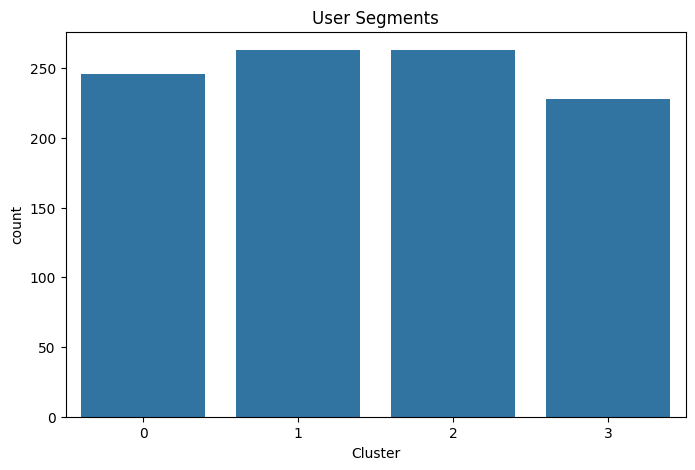

In [14]:
#visulalization
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title(
    "User Segments"
)

plt.show()

In [15]:
#Average Productivity by Interest
recommendation = df.groupby(
    "Dominant_Interest"
)["Productivity_Score"].mean()

recommendation = recommendation.sort_values(
    ascending=False
)

print(recommendation)

Dominant_Interest
Sports           53.236364
Data Science     50.850299
Cybersecurity    50.782123
Gaming           50.568047
AI               50.443114
Reading          49.189542
Name: Productivity_Score, dtype: float64


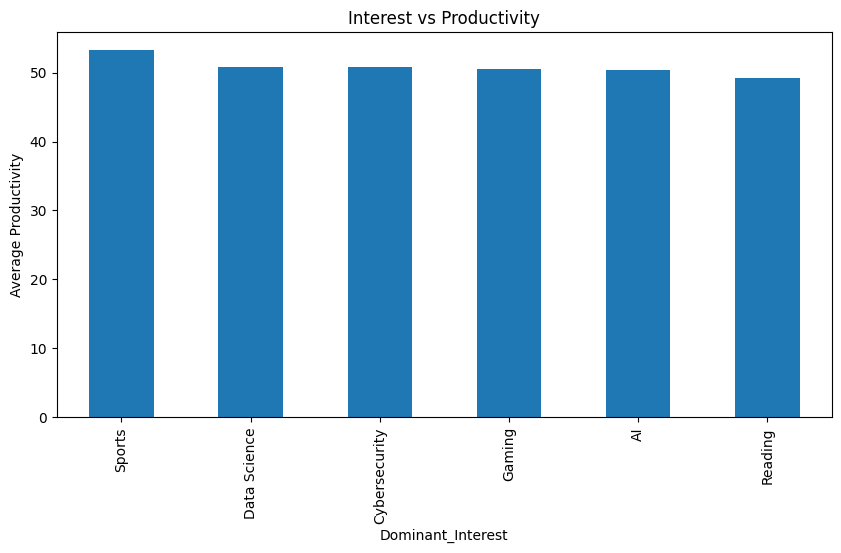

In [16]:
#top interest
recommendation.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Interest vs Productivity"
)

plt.ylabel(
    "Average Productivity"
)

plt.show()

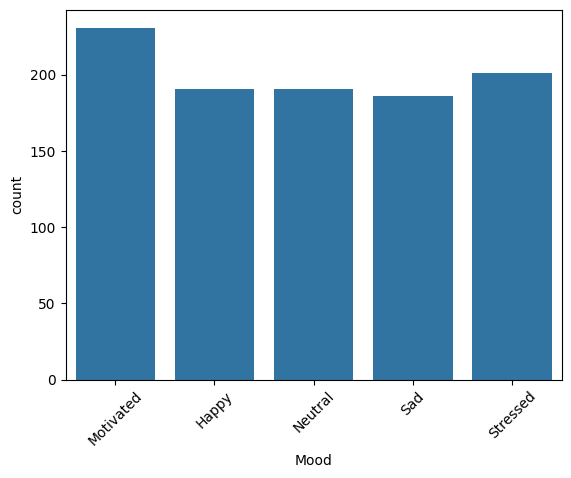

In [17]:
#mood analysis
sns.countplot(
    data=df,
    x="Mood"
)

plt.xticks(rotation=45)
plt.show()

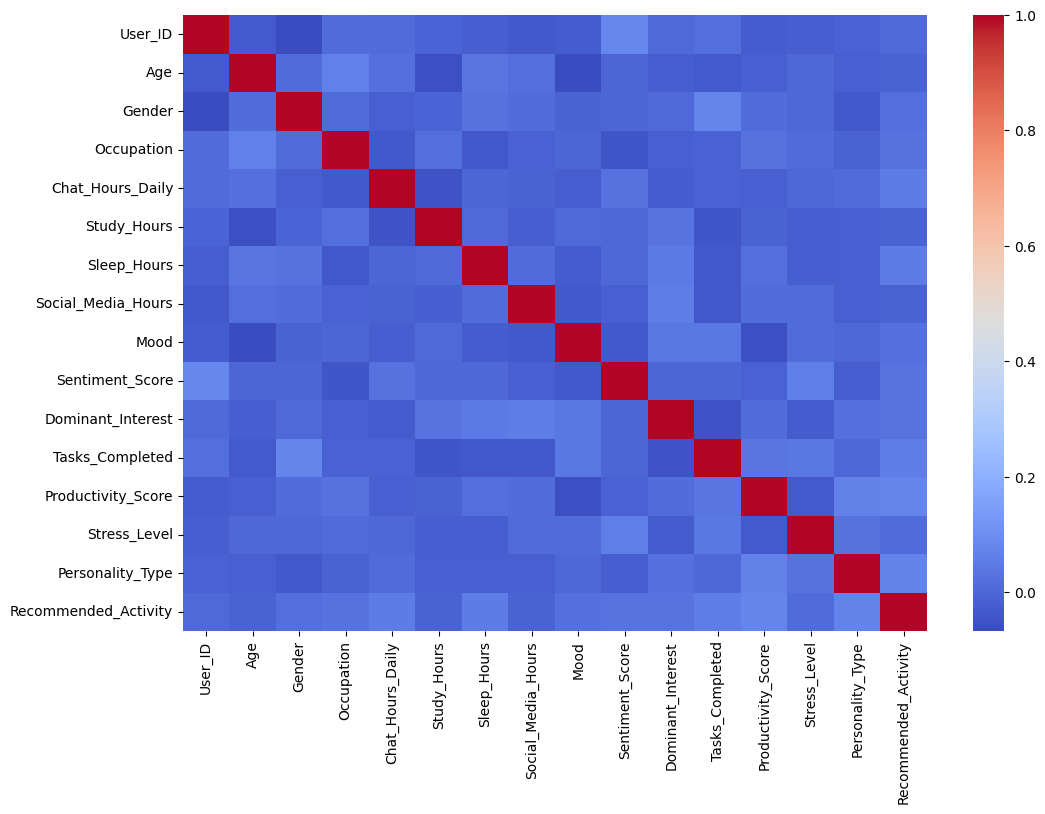

In [19]:
#correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df_ml.corr(),
    annot=False,
    cmap="coolwarm"
)

plt.show()

In [20]:
#sae train model
import joblib

joblib.dump(
    clf,
    "personality_model.pkl"
)

joblib.dump(
    reg,
    "productivity_model.pkl"
)

joblib.dump(
    kmeans,
    "cluster_model.pkl"
)

print("Models Saved Successfully!")

Models Saved Successfully!
